In [28]:
import pandas as pd
import sqlite3

# Connect to the database we built in data understanding phase
conn = sqlite3.connect('oilst_ecommerce.db')

def run_query(query):
    return pd.read_sql_query(query, conn)

#### What are the top 10 product categories by total revenue and order count?

In [29]:
query_1 = """
    SELECT 
        products.product_category
        ,SUM(order_items.price) AS total_revenue 
        ,COUNT(DISTINCT orders.order_id) AS total_orders
        
    FROM orders 
    JOIN order_items 
        ON orders.order_id = order_items.order_id
    JOIN products 
        ON order_items.product_id = products.product_id

    WHERE orders.order_status = 'delivered' 
      AND orders.order_delivered_customer_date IS NOT NULL

    GROUP BY products.product_category
    ORDER BY total_revenue DESC
    LIMIT 10;
"""
# We extract the needed columns calculating the revenue using price and counting the unique order ids.
# We join order items table with orders and products tables on the IDs
# We check on whether the status is 'delivered' and there exists a customer delivery date
# We perform grouping by category and ensure clear output by ordering and limiting to top 10

top_categories_df = run_query(query_1)
display(top_categories_df)

,product_category,total_revenue,total_orders
0,Health Beauty,1233131.72,8647
1,Watches Gifts,1165898.98,5493
2,Bed Bath Table,1023434.76,9272
3,Sports Leisure,954673.55,7529
4,Computers Accessories,888613.62,6529
5,Furniture Decor,711927.69,6307
6,Housewares,615628.69,5743
7,Cool Stuff,610204.10,3559
8,Auto,578849.35,3809
9,Toys,471097.49,3803


#### Observations:
- Revenue drivers: It is clearly noticable that 'Health & Beauty' and 'Watches & Gifts' are the top revenue generators, with the latter totalling only ~5.4% less.

- Volume & Revenue: While 'Watches Gifts' drives massive revenue, 'Bed Bath Table' brings the highest absolute order volume among the Top 10. This means that the average order value is smaller and the group may cost more in logistics to generate the same amount of revenue.

#### How do total revenue and order volume trend by month? Identify any seasonal patterns.

In [30]:
query_2 = """
    SELECT 
        strftime('%Y-%m', orders.order_purchase_timestamp) AS Month
        ,SUM(order_items.price) AS total_revenue
        ,COUNT(DISTINCT orders.order_id) AS total_orders

    FROM orders
    JOIN order_items 
        ON orders.order_id = order_items.order_id

    WHERE orders.order_status = 'delivered' 
      AND orders.order_delivered_customer_date IS NOT NULL
      
    GROUP BY Month
    ORDER BY Month ASC;
"""
# strftime() is used here as it is 
# Orders are joined with order items
# We also filter out to only the orders that were delivered and that have the delivery date 
# We select the revenue and orders amount, groupping it by month and ordering chronologically
by_month = run_query(query_2)
display(by_month)

,Month,total_revenue,total_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489159.25,3545
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872


Even though there are only 23 Month it is much more representative to draw a quick line chart of how the variables progress.

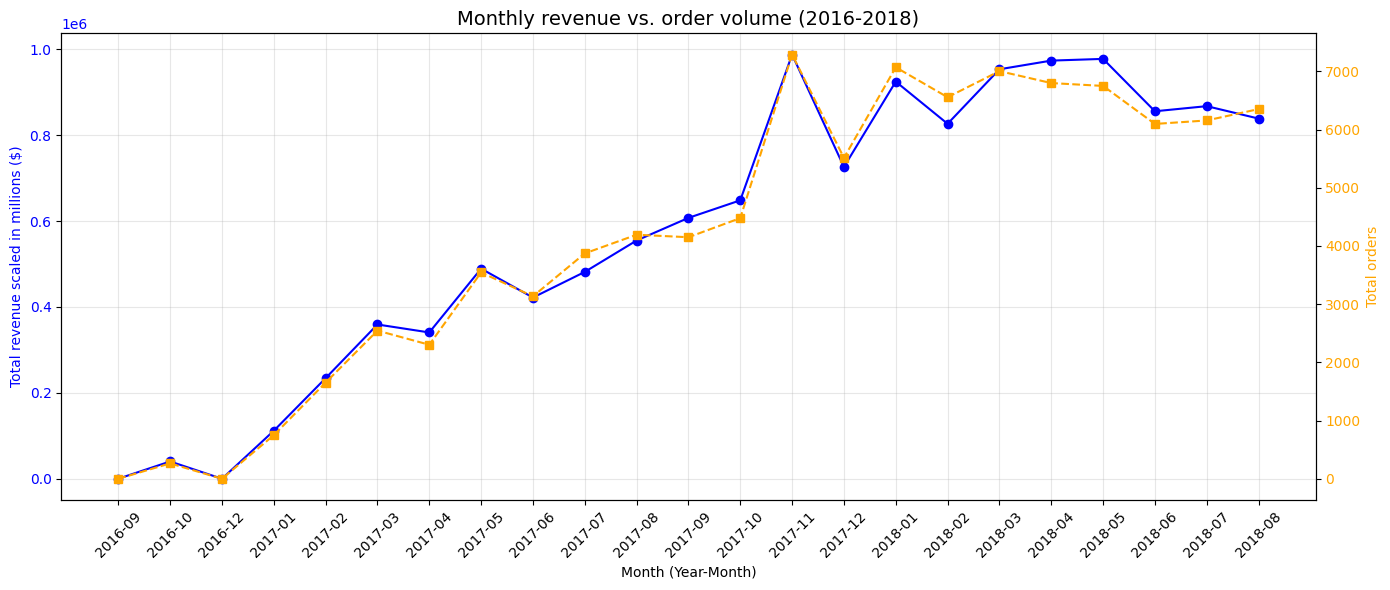

In [31]:
import matplotlib.pyplot as plt

# Set up the plot with a dual y-axis for the revenue and order count
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot revenue on the left axis (blue)
ax1.set_xlabel('Month (Year-Month)')
ax1.set_ylabel('Total revenue scaled in millions ($)', color='blue')
ax1.plot(by_month['Month'], by_month['total_revenue'], color='blue', marker='o', label='Revenue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot order count on the right axis (orange)
ax2 = ax1.twinx()
ax2.set_ylabel('Total orders', color='orange')
ax2.plot(by_month['Month'], by_month['total_orders'], color='orange', marker='s', linestyle='--', label='Orders')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and layout
plt.title('Monthly revenue vs. order volume (2016-2018)', fontsize=14)
fig.tight_layout()

# Show the plot
plt.show()

#### Observations:

Chart illustrates a clear trend of the coupled growth in both revenue and order volume from its full launch in Q1 2017 through mid-2018.
The data gap in late 2016 (specifically November) reflects Olist's initial pilot phase and operational pause, while it still made initial sales in 2016-10.

November 2017 represents the platform's highest historic peak (7,288 orders, ~$987k revenue). The subsequent ~27.5% revenue drop in December 2017 may be exlained by the post-holiday decline. 
We can also notice that the 4 month period after the rapid spike in sales of 2017-10 was fluctuative and after peaking in May 2018, the platform experienced a slight stagnation/decline (~12.5% drop in revenue by August 2018). 

After peaking in May 2018, the platform experienced a decline (~12.5% drop in revenue by August 2018).

*Note: October 2018 data may be incomplete due to the database extraction cutoff date.* 



In [32]:
query_3 = """
SELECT 
    customers.customer_state AS state
    ,SUM(order_items.price) AS total_revenue
    ,COUNT(DISTINCT orders.order_id) AS total_orders

FROM customers
JOIN orders 
    ON customers.customer_id = orders.customer_id
JOIN order_items
    ON orders.order_id = order_items.order_id

WHERE order_status = 'delivered' 
    AND order_delivered_customer_date IS NOT NULL 

GROUP BY customers.customer_state
ORDER BY total_revenue DESC
"""
# We take the customers state from customers and also calculate revenue and orders amount
# We perform joins on customer_id (not customer_id_unique as was defined previously) and order_id
# The inner joins also delete any customers without orders. 
# We also filter only to delivered orders with a delivery date
# We group and output in descending manner

by_state = run_query(query_3)
display(by_state)

,state,total_revenue,total_orders
0,SP,5066562.98,40494
1,RJ,1759651.13,12350
2,MG,1552481.83,11354
3,RS,728718.47,5344
4,PR,666063.51,4923
5,SC,507012.13,3546
6,BA,493584.14,3256
7,DF,296498.41,2080
8,GO,282836.70,1957
9,ES,268643.45,1995


The leading state is San Paolo, with revenue bein about 3 times higher then in the second and 3rd states of Rio de Janeiro and Minas Gerais. This is quite predictable as SP is the most developed and populated state of Brasil. Other states are quite decoupled from the top-3 as the amount of sales in Rio Grande do Sul is about 2 times lower then the one of MG. This indicates that the vast amount of sales comes from the South-East of the country. 

#### Observations:

- The Southeast leadership: The top three states — São Paulo (SP), Rio de Janeiro (RJ), and Minas Gerais (MG) are dominating the platform's volume.

- SP decouple: The leading state is São Paulo, generating about $5.06M in revenue. This is roughly 3 times higher than the second-place state (RJ at ~$1.75M).

- Gap in value: Beyond the top three, revenue volume fractures significantly. Other states are quite decoupled from the top-3 as the amount of sales in Rio Grande do Sul is about 2 times lower then the one of Minas Gerais (MG).
This indicates that the logistic hubs of the firm should be located in accordance with this, while further expansion to underserved regions might be of the company's interest.

#### Identify and analyze unmatched or incomplete records (for example, products with no sales, customers with no orders, or canceled orders). What does this reveal?

In [33]:
WITH status_unclear AS(
    SELECT order_id
    FROM olist_orders_dataset
    WHERE order_status = 'delivered' 
        AND order_delivered_customer_date IS NULL
)
, canceled AS(
    SELECT order_id
    FROM orders
    WHERE order_status = 'canceled' 
        OR order_status = 'unavailable' 
        OR order_delivered_customer_date IS NULL
) 
, no_items AS(
    SELECT order_id
    FROM olist_order_items_dataset
    JOIN 
    GROUP BY order_id
    HAVING COUNT(product_id) = 0
)

SELECT 
    COUNT(DISTINCT orders.order_id) AS total_orders
    ,((COUNT(DISTINCT status_unclear.order_id)/COUNT(DISTINCT orders.order_id))*100) AS percentage_of_unclear_status
    ,((COUNT(DISTINCT canceled.order_id)/COUNT(DISTINCT orders.order_id))*100) AS percentage_of_canceled_orders
    ,((COUNT(DISTINCT no_items.order_id)/COUNT(DISTINCT orders.order_id))*100) AS percentage_of_orders_with_no_items

FROM order_items 

LEFT JOIN olist_orders_dataset orders
    ON orders.order_id = order_items.order_id

SyntaxError: unmatched ')' (4275128981.py, line 13)

In [ ]:
SELECT 
    COUNT(orders.order_id) AS total_orders
    
    ,ROUND(CAST(SUM(
        CASE WHEN order_status = 'delivered' 
        AND order_delivered_customer_date IS NULL THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(orders.order_id) * 100, 2) 
        AS pct_unclear_status
    
    ,ROUND(CAST(SUM(
        CASE WHEN order_status IN ('canceled', 'unavailable') 
        OR order_delivered_customer_date IS NULL THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(orders.order_id) * 100, 2) 
        AS pct_canceled_or_failed
    
    ,ROUND(CAST(SUM(
        CASE WHEN items.total_items IS NULL THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(orders.order_id) * 100, 2) 
        AS pct_orders_no_items

FROM orders
LEFT JOIN (
    SELECT order_id, COUNT(product_id) AS total_items 
    FROM order_items 
    GROUP BY order_id
) items 
    ON orders.order_id = items.order_id;

In [ ]:
query_4 = """
SELECT 
    COUNT(orders.order_id) AS total_orders
    
    ,ROUND(CAST(SUM(
        CASE WHEN order_status = 'delivered' 
        AND order_delivered_customer_date IS NULL THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(orders.order_id) * 100, 2) 
        AS pct_unclear_status
    
    ,ROUND(CAST(SUM(
        CASE WHEN order_status IN ('canceled', 'unavailable') 
        OR order_delivered_customer_date IS NULL THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(orders.order_id) * 100, 2) 
        AS pct_canceled_or_failed
    
    ,ROUND(CAST(SUM(
        CASE WHEN items.total_items IS NULL THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(orders.order_id) * 100, 2) 
        AS pct_orders_no_items

FROM orders
LEFT JOIN (
    SELECT order_id, COUNT(product_id) AS total_items 
    FROM order_items 
    GROUP BY order_id
) items 
    ON orders.order_id = items.order_id;
"""

data_quality_df = run_query(query_4)
display(data_quality_df)

,total_orders,pct_unclear_status,pct_canceled_or_failed,pct_orders_no_items
0,99441,0.01,2.99,0.78


In [36]:
query_5 = """
WITH customer_metrics AS (
    SELECT 
        customers.customer_unique_id,
        COUNT(orders.order_id) AS lifetime_orders,
        SUM(CASE WHEN orders.order_status = 'canceled' THEN 1 ELSE 0 END) AS lifetime_cancels
    FROM customers
    LEFT JOIN orders 
        ON customers.customer_id = orders.customer_id
    GROUP BY customers.customer_unique_id
)

SELECT 
    COUNT(customer_unique_id) AS total_unique_customers

    ,ROUND(CAST(SUM(
        CASE WHEN lifetime_orders = 0 THEN 1
        ELSE 0 END) AS FLOAT) / 
        COUNT(customer_unique_id) * 100, 2) 
        AS pct_zero_orders

    ,ROUND(CAST(SUM(
        CASE WHEN lifetime_orders = 1 THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(customer_unique_id) * 100, 2) 
        AS pct_one_order
    
    ,ROUND(CAST(SUM(
        CASE WHEN lifetime_orders > 1 THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(customer_unique_id) * 100, 2) 
        AS pct_repeat_customers
    
    ,ROUND(CAST(SUM(
        CASE WHEN lifetime_cancels = lifetime_orders AND lifetime_orders > 0 THEN 1 
        ELSE 0 END) AS FLOAT) / 
        COUNT(customer_unique_id) * 100, 2) 
        AS pct_with_churn
FROM customer_metrics;
"""

customer_funnel_df = run_query(query_5)
display(customer_funnel_df)

,total_unique_customers,pct_zero_orders,pct_one_order,pct_repeat_customers,pct_with_churn
0,96096,0.0,96.88,3.12,0.56


In [ ]:
# 1. SQL extraction
query_6 = """
    SELECT 
        order_id,
        julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS delivery_days
    FROM orders
    WHERE order_status = 'delivered' 
      AND order_delivered_customer_date IS NOT NULL
      AND order_purchase_timestamp IS NOT NULL;
"""

delivery_df = run_query(query_6)

# 2. Statistical analysis of outliers
# Calculate the metrics
mean_delivery = delivery_df['delivery_days'].mean()
std_delivery = delivery_df['delivery_days'].std()

# We define the thresold of 1 and 2 standard deviaton to perform an initial anlysis of the firm's delivery time ditribution
sla_threshold1 = mean_delivery + std_delivery
sla_threshold2 = mean_delivery + 2*std_delivery

# Counting how many fall above breached this thresholds
outliers_df1 = delivery_df[delivery_df['delivery_days'] > sla_threshold1]
pct_outliers1 = (len(outliers_df1) / len(delivery_df)) * 100

outliers_df2 = delivery_df[delivery_df['delivery_days'] > sla_threshold2]
pct_outliers2 = (len(outliers_df2) / len(delivery_df)) * 100


# Print the summary
print("Summary:")
print(f"Average delivery time: {mean_delivery:.2f} days")
print(f"Standard deviation:    {std_delivery:.2f} days")
print(f"Threshold of 1 standard deviation > {sla_threshold1:.2f} days")
print(f"Orders above 1 std:  {len(outliers_df1):,} orders")
print(f"Percantage rate: {pct_outliers1:.2f}%")
print(f"Threshold of 2 standard deviation > {sla_threshold2:.2f} days")
print(f"Orders above 2 std:  {len(outliers_df2):,} orders")
print(f"Percantage rate: {pct_outliers2:.2f}%")

Summary:
Average delivery time: 12.56 days
Standard deviation:    9.55 days
Threshold of 1 standard deviation > 22.10 days
Orders above 1 std:  10,820 orders
Percantage rate:          11.22%
Threshold of 2 standard deviation > 31.65 days
Orders above 2 std:  3,877 orders
Percantage rate:          4.02%


In [43]:
import os

# Create the target directory so it doesn't crash if it doesn't exist
output_dir = 'data/clean'
os.makedirs(output_dir, exist_ok=True)

print("Connect to database and extract the tables:")

# Get a list of all tables in the SQLite database
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = run_query(tables_query)['name'].tolist()

# Loop through and export each table
for table in tables:
    print(f"Exporting '{table}'...")
    df = run_query(f"SELECT * FROM {table};")
    output_path = os.path.join(output_dir, f"{table}_clean.csv")
    df.to_csv(output_path, index=False)
    print(f"Saved to {output_path} ({len(df):,} rows)")

print("\nData is ready for export in Power BI.")

Connect to database and extract the tables:
Exporting 'customers'...
Saved to data/clean\customers_clean.csv (99,441 rows)
Exporting 'orders'...
Saved to data/clean\orders_clean.csv (99,441 rows)
Exporting 'order_items'...
Saved to data/clean\order_items_clean.csv (112,650 rows)
Exporting 'products'...
Saved to data/clean\products_clean.csv (32,951 rows)

Data is ready for export in Power BI.
